<a href="https://colab.research.google.com/github/Pablolpl/ml-finanzas/blob/main/practica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 3 · Predicción del S&P 500 con redes LSTM

**Máster en IA Aplicada al Sector Financiero — Instituto Europeo de Posgrado**

**Objetivo:** aplicar técnicas de *Deep Learning* para predecir el precio de cierre del índice S&P 500 a partir de su propio histórico, usando una red neuronal recurrente LSTM.

**Datos:** `Index2018.csv`, con la fecha (`date`) y los precios de cierre diarios de cuatro índices bursátiles: S&P 500 (EE. UU.), DAX 30 (Alemania), FTSE 100 (Londres) y NIKKEI 225 (Japón). En esta práctica se utiliza únicamente el S&P 500 (`spx`).

**Estructura del notebook**
1. Creación del notebook
2. Carga de datos y verificación de tipos
3. Análisis de valores faltantes
4. División train / test
5. Normalización de los datos
6. Generador de series temporales
7. Creación y entrenamiento del modelo
8. Aplicación del modelo al conjunto de test
9. Evaluación complementaria: comparación con un modelo ingenuo

## 1. Creación del notebook

Este cuaderno se ha creado en Google Colab con el nombre **`Practica3.ipynb`**.

Un *notebook* es un tipo de archivo que permite escribir y ejecutar código paso a paso, combinando celdas de código con celdas de texto y mostrando los resultados directamente debajo de cada celda. La extensión `.ipynb` significa *IPython Notebook*, el formato estándar de estos cuadernos cuando se trabaja con Python.

No es necesario activar GPU: con `batch_size = 1` y una LSTM con activación `relu`, la ganancia de velocidad es mínima, por lo que el entorno de CPU por defecto es suficiente.

## 2. Carga de datos

### 2.1 Subida del archivo a Colab

La siguiente celda abre un botón para seleccionar el archivo `Index2018.csv` desde el ordenador. El archivo se guarda en el directorio de trabajo del entorno de Colab.

> ⚠️ El archivo se borra cuando el entorno se desconecta, por lo que hay que volver a subirlo en cada sesión.

In [1]:
# Importamos la utilidad de Colab para subir archivos desde el ordenador
from google.colab import files

# Abre el selector de archivos: elegir Index2018.csv
uploaded = files.upload()

Saving Index2018.csv to Index2018 (4).csv


In [2]:
# Verificamos que el archivo está en el directorio de trabajo
import os

nombre_archivo = 'Index2018.csv'
if os.path.exists(nombre_archivo):
    print(f"✔ Archivo '{nombre_archivo}' cargado correctamente "
          f"({os.path.getsize(nombre_archivo) / 1024:.1f} KB)")
else:
    print(f"✘ No se encuentra '{nombre_archivo}'. Archivos disponibles: {os.listdir()}")

✔ Archivo 'Index2018.csv' cargado correctamente (290.7 KB)


### 2.2 Lectura del archivo con pandas

Utilizamos la librería **pandas**, que permite trabajar con datos en forma de tabla (*DataFrame*), de forma similar a una hoja de Excel: ver, filtrar, ordenar y analizar los datos.

Leemos el archivo `Index2018.csv` con tres parámetros:
- `usecols=['spx', 'date']`: cargamos solo la fecha y el S&P 500, ya que el resto de columnas no se utilizan.
- `index_col='date'`: la fecha pasa a ser el índice de la tabla.
- `sep=';'`: el archivo usa el **punto y coma** como separador de columnas, formato habitual en los CSV exportados con configuración regional europea, donde la coma se reserva para los decimales.

A diferencia de un Excel, un CSV es texto plano: pandas no convierte automáticamente las fechas ni los números con coma decimal. Por eso, en el apartado 2.3 se verifica el tipo de cada columna y se corrige lo necesario.

Con `head(N)` mostramos las primeras N filas para ver la estructura de la tabla.

In [3]:
# Importamos pandas con su alias habitual
import pandas as pd

# Leemos solo las columnas necesarias, con la fecha como índice
df = pd.read_csv('Index2018.csv',
                 usecols=['spx', 'date'],
                 index_col='date',
                 sep=';')  # el archivo usa punto y coma como separador

# Mostramos las 5 primeras filas
df.head(5)

,spx
date,
1994-01-07,"469,9"
1994-01-10,"475,27"
1994-01-11,"474,13"
1994-01-12,"474,17"
1994-01-13,"472,47"


### 2.3 Verificación de los tipos de datos

Comprobamos que el tipo de dato que infiere Python para cada columna es el correcto:
- El **índice** debe ser de tipo fecha (`DatetimeIndex`, `datetime64`). Si fuera texto (`object`), no podríamos aplicar frecuencias de días hábiles ni filtrar por fechas.
- La columna **`spx`** debe ser numérica decimal (`float64`), ya que contiene precios.

Además verificamos dos requisitos para trabajar con series temporales: que las fechas estén **ordenadas** cronológicamente y que **no haya fechas duplicadas**.

In [4]:
# Resumen general: nº de filas, tipo del índice, tipo de cada columna y valores no nulos
df.info()

print("\n--- Comprobaciones de tipo (ANTES de corregir) ---")
print("Tipo del índice :", df.index.dtype)
print("Tipo de 'spx'   :", df['spx'].dtype)
print("¿Índice de tipo fecha?:", pd.api.types.is_datetime64_any_dtype(df.index))

<class 'pandas.core.frame.DataFrame'>
Index: 6269 entries, 1994-01-07 to 2018-01-29
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   spx     6269 non-null   object
dtypes: object(1)
memory usage: 98.0+ KB

--- Comprobaciones de tipo (ANTES de corregir) ---
Tipo del índice : object
Tipo de 'spx'   : object
¿Índice de tipo fecha?: False


In [5]:
# Corrección de tipos (solo actúa si algún tipo no es el esperado)
cambios = []

# Si el índice no es de tipo fecha, lo convertimos.
# Las fechas vienen en formato ISO (AAAA-MM-DD), por lo que no hay ambigüedad entre día y mes
if not pd.api.types.is_datetime64_any_dtype(df.index):
    df.index = pd.to_datetime(df.index)
    cambios.append("índice convertido de texto a fecha (YYYY-MM-DD)")

# Si 'spx' no es numérico decimal, lo convertimos.
# El archivo usa coma decimal (469,9): primero la sustituimos por punto y después convertimos a número
if not pd.api.types.is_float_dtype(df['spx']):
    df['spx'] = df['spx'].astype(str).str.replace(',', '.', regex=False)
    df['spx'] = pd.to_numeric(df['spx'], errors='coerce').astype('float64')
    cambios.append("'spx' convertido a float64 (comas reemplazadas por puntos)")

# Si las fechas no están ordenadas, las ordenamos
if not df.index.is_monotonic_increasing:
    df = df.sort_index()
    cambios.append("índice ordenado cronológicamente")

print("Cambios realizados:", ", ".join(cambios) if cambios else "ninguno, los tipos inferidos eran correctos")

print("\n--- Comprobaciones de tipo (DESPUÉS de corregir) ---")
print("Tipo del índice :", df.index.dtype)
print("Tipo de 'spx'   :", df['spx'].dtype)
print("¿Índice ordenado cronológicamente?:", df.index.is_monotonic_increasing)
print("¿Fechas sin duplicados?           :", df.index.is_unique)

Cambios realizados: índice convertido de texto a fecha (YYYY-MM-DD), 'spx' convertido a float64 (comas reemplazadas por puntos)

--- Comprobaciones de tipo (DESPUÉS de corregir) ---
Tipo del índice : datetime64[ns]
Tipo de 'spx'   : float64
¿Índice ordenado cronológicamente?: True
¿Fechas sin duplicados?           : True


In [6]:
# Comprobamos que fechas y precios se han convertido correctamente
print("Primera fecha:", df.index[0].date(), "| Valor:", df['spx'].iloc[0])
print("Última fecha :", df.index[-1].date())
print(f"Total: {len(df)} observaciones")
# Esperado: primera fecha 1994-01-07 con valor 469.9 (igual que el enunciado)

Primera fecha: 1994-01-07 | Valor: 469.9
Última fecha : 2018-01-29
Total: 6269 observaciones


**Comentario — ¿cómo lo verifiqué?**

Verifiqué los tipos de datos con `df.info()`, que muestra el tipo del índice y de cada columna, y los confirmé de forma explícita con `df.index.dtype` y `df['spx'].dtype`. La salida mostró que **ninguno de los dos tipos inferidos por Python era correcto**:

- **Índice (`date`): se leyó como `object` (texto).** Al tratarse de un CSV, las fechas se almacenan como cadenas de caracteres y pandas no las convierte salvo que se le indique. Como vienen en formato ISO (AAAA-MM-DD), las convertí con `pd.to_datetime(df.index)` sin riesgo de confundir día y mes.
- **Precio (`spx`): se leyó como `object` en lugar de `float64`.** El archivo usa la coma como separador decimal (por ejemplo, `469,9`), mientras que pandas espera un punto, por lo que interpretó los precios como texto. Sustituí la coma por el punto y convertí la columna a `float64` con `pd.to_numeric()`. Sin esta corrección no sería posible escalar los datos ni entrenar el modelo.

Tras la corrección, el índice es un `DatetimeIndex` de tipo `datetime64[ns]` y `spx` es `float64`. Comprobé que la conversión conserva los valores originales: la serie tiene 6.269 observaciones, la primera corresponde al 07/01/1994 con 469,90 puntos (igual que en el enunciado) y la última al 29/01/2018. La conversión no generó valores nulos: los únicos faltantes que aparecen en el paso 3 corresponden a fechas añadidas por `asfreq()`, no a precios mal convertidos. Por último, comprobé con `is_monotonic_increasing` e `is_unique` que las fechas quedan ordenadas y sin duplicados, condiciones necesarias para aplicar la frecuencia de días hábiles.

> Una alternativa equivalente habría sido indicarlo directamente en la lectura: `pd.read_csv(..., sep=';', decimal=',', parse_dates=True)`. Se ha optado por verificar y corregir por separado para documentar el problema, tal como pide el enunciado.necesarias para aplicar después la frecuencia de días hábiles con `asfreq()`.

## 3. Análisis de valores faltantes

En series temporales es clave revisar si faltan fechas: si faltan datos de varios días, el modelo no se da cuenta de que ha pasado tiempo entre dos observaciones consecutivas.

Como trabajamos con precios de un activo financiero, esperamos datos solo en **días hábiles**. Con `asfreq('B')` (*business days*) forzamos una frecuencia de lunes a viernes: si falta algún día hábil, pandas inserta la fecha con valor `NaN`.

Después completamos esos huecos con el **último valor conocido** (*forward fill*).

> **Nota técnica:** el enunciado usa `fillna(method='ffill')`. Ese parámetro está obsoleto en las versiones actuales de pandas y puede producir error, por lo que se utiliza `df.ffill()`, que realiza exactamente la misma operación.

In [7]:
# Guardamos el nº de filas original para compararlo
n_antes = len(df)

# Aplicamos al índice (fecha) una frecuencia diaria de días hábiles.
# Esto insertará NaN donde falten días hábiles
df = df.asfreq('B')

print(f"Filas antes de asfreq('B') : {n_antes}")
print(f"Filas después              : {len(df)}")
print(f"Nº de valores faltantes    : {df['spx'].isna().sum()}")

Filas antes de asfreq('B') : 6269
Filas después              : 6277
Nº de valores faltantes    : 8


In [8]:
# Identificamos las fechas faltantes ANTES de rellenarlas
faltantes = df[df['spx'].isna()]

tabla_faltantes = pd.DataFrame({
    'fecha': faltantes.index.date,
    'día de la semana': faltantes.index.day_name(),
    'valor con el que se rellena (último conocido)': df['spx'].ffill()[faltantes.index].values
})
tabla_faltantes

,fecha,día de la semana,valor con el que se rellena (último conocido)
0,2008-01-01,Tuesday,1468.355174
1,2009-01-01,Thursday,903.254921
2,2010-01-01,Friday,1115.102681
3,2013-01-01,Tuesday,1426.187978
4,2014-01-01,Wednesday,1848.356521
5,2015-01-01,Thursday,2058.902379
6,2016-01-01,Friday,2043.936863
7,2018-01-01,Monday,2673.610523


In [9]:
# Completamos los NaN con el último valor conocido
df = df.ffill()

# Verificación: no debe quedar ningún valor faltante
print("Valores faltantes tras el relleno:", df['spx'].isna().sum())
print("Frecuencia del índice:", df.index.freqstr)

Valores faltantes tras el relleno: 0
Frecuencia del índice: B


In [10]:
# Resumen automático de los valores faltantes (apoya el comentario escrito)
n_falt = len(tabla_faltantes)
if n_falt == 0:
    print("No había días hábiles faltantes en la serie.")
else:
    fechas_txt = ", ".join(pd.to_datetime(tabla_faltantes['fecha']).dt.strftime('%d/%m/%Y'))
    dias = tabla_faltantes['día de la semana'].value_counts().to_dict()
    print(f"Se detectaron {n_falt} días hábiles sin dato: {fechas_txt}.")
    print(f"Distribución por día de la semana: {dias}.")
    print(f"Representan un {n_falt / len(df):.3%} del total de observaciones.")

Se detectaron 8 días hábiles sin dato: 01/01/2008, 01/01/2009, 01/01/2010, 01/01/2013, 01/01/2014, 01/01/2015, 01/01/2016, 01/01/2018.
Distribución por día de la semana: {'Tuesday': 2, 'Thursday': 2, 'Friday': 2, 'Wednesday': 1, 'Monday': 1}.
Representan un 0.127% del total de observaciones.


**Comentario — ¿cuáles eran los valores faltantes?**

Al aplicar `asfreq('B')`, la serie pasa de 6.269 a 6.277 filas: había **8 días hábiles** que no figuraban en el archivo. Los ocho son **1 de enero**, en concreto de 2008, 2009, 2010, 2013, 2014, 2015, 2016 y 2018, años en los que esa fecha cayó entre lunes y viernes.

La explicación es que el 1 de enero es festivo en las cuatro bolsas del archivo (Nueva York, Fráncfort, Londres y Tokio), por lo que no hubo cotización. `asfreq('B')` considera hábil cualquier día de lunes a viernes, pero no conoce el calendario de festivos, por lo que detecta estas fechas como huecos. Otros festivos sí figuran en el archivo con valor (por ejemplo, el 25/12/2017 aparece en las últimas filas de train), por lo que los únicos huecos de la serie son estos ocho días de Año Nuevo.

Los rellené con el último precio de cierre disponible (*forward fill*), que equivale a suponer que el precio no cambió ese día, lo cual es coherente con un día sin mercado. El impacto es mínimo: representan un 0,127 % de las observaciones y solo introducen ocho días con rentabilidad del 0 %.

Hay un detalle a tener en cuenta: el último hueco, el **01/01/2018, es la primera fila del conjunto de test**, y queda rellenado con el cierre del 29/12/2017 (2.673,61 puntos), que es el último dato de train. No supone fuga de información, porque se usa un dato del pasado, pero el test empieza con un valor imputado.

## 4. División train / test

Antes de analizar o transformar los datos, separamos el conjunto en dos partes: **entrenamiento (train)** y **validación (test)**. Esto se hace al principio para simular que no conocemos el test y evitar sacar conclusiones con información que no deberíamos ver.

Como los datos son secuenciales, **no se pueden separar al azar**: se usan los datos anteriores al 01/01/2018 para entrenar y los posteriores para validar. Una separación aleatoria permitiría al modelo "ver el futuro" durante el entrenamiento.

In [11]:
# Fecha de corte entre entrenamiento y test
fecha_corte = '2018-01-01'

# Train: datos anteriores a la fecha de corte
train = df[df.index < fecha_corte]

# Test: datos desde la fecha de corte en adelante
test = df[df.index >= fecha_corte]

print(f"Train: {train.shape[0]} filas | de {train.index.min().date()} a {train.index.max().date()}")
print(f"Test : {test.shape[0]} filas | de {test.index.min().date()} a {test.index.max().date()}")

Train: 6256 filas | de 1994-01-07 a 2017-12-29
Test : 21 filas | de 2018-01-01 a 2018-01-29


In [12]:
# Verificamos el filtro de TRAIN con head() y tail()
print("TRAIN — primeras filas:")
display(train.head(5))
print("TRAIN — últimas filas:")
display(train.tail(5))

TRAIN — primeras filas:


,spx
date,
1994-01-07,469.90
1994-01-10,475.27
1994-01-11,474.13
1994-01-12,474.17
1994-01-13,472.47


TRAIN — últimas filas:


,spx
date,
2017-12-25,2683.337274
2017-12-26,2680.504486
2017-12-27,2682.619923
2017-12-28,2687.537829
2017-12-29,2673.610523


In [13]:
# Verificamos el filtro de TEST con head() y tail()
print("TEST — primeras filas:")
display(test.head(5))
print("TEST — últimas filas:")
display(test.tail(5))

TEST — primeras filas:


,spx
date,
2018-01-01,2673.610523
2018-01-02,2695.809772
2018-01-03,2713.061006
2018-01-04,2723.992595
2018-01-05,2743.147773


TEST — últimas filas:


,spx
date,
2018-01-23,2839.130362
2018-01-24,2837.544008
2018-01-25,2839.253031
2018-01-26,2872.867839
2018-01-29,2853.528411


In [14]:
# Comprobaciones formales del filtro
print("¿Última fecha de train < 01/01/2018?  :", train.index.max() < pd.Timestamp(fecha_corte))
print("¿Primera fecha de test >= 01/01/2018? :", test.index.min() >= pd.Timestamp(fecha_corte))
print("¿Train + test = total (sin pérdidas)? :", len(train) + len(test) == len(df))
print("¿Sin fechas compartidas?              :", train.index.intersection(test.index).empty)

¿Última fecha de train < 01/01/2018?  : True
¿Primera fecha de test >= 01/01/2018? : True
¿Train + test = total (sin pérdidas)? : True
¿Sin fechas compartidas?              : True


**Comentario — verificación de los filtros**

Con `head()` y `tail()` comprobé que el conjunto de entrenamiento (6.256 filas) empieza el 07/01/1994 y termina el 29/12/2017, último día hábil de 2017, y que el conjunto de test (21 filas) empieza el 01/01/2018 y termina el 29/01/2018, final de la serie. Lo confirmé con cuatro comprobaciones formales, todas con resultado `True`: la última fecha de train es anterior al corte, la primera de test es igual o posterior, entre ambos suman las 6.277 observaciones totales y no comparten ninguna fecha.

Hay un aspecto importante a tener en cuenta: el test es **muy corto**, 21 días hábiles frente a más de 24 años de entrenamiento. Como el modelo necesita 15 días como entrada, solo quedarán **6 predicciones** (del 22 al 29 de enero de 2018), lo que limita mucho la fiabilidad de cualquier conclusión sobre su rendimiento.

## 5. Normalización de los datos

Las redes neuronales funcionan mejor con datos escalados. Se utiliza `StandardScaler()` de la librería `scikit-learn`.

El escalador se **ajusta solo con los datos de entrenamiento** y después se usa para transformar tanto train como test, simulando un escenario real en el que no conocemos los datos futuros.

In [15]:
# Importamos la función que vamos a utilizar de la librería sklearn
from sklearn.preprocessing import StandardScaler

# Ajustamos el escalador SOLO con el conjunto de entrenamiento
scaler = StandardScaler()
scaler.fit(train[['spx']])

# Transformamos los datos de entrenamiento y de test con los parámetros de train
scaled_train = scaler.transform(train[['spx']])
scaled_test = scaler.transform(test[['spx']])

In [16]:
# Parámetros aprendidos por el escalador (calculados únicamente con train)
mu = scaler.mean_[0]
sigma = scaler.scale_[0]
print(f"Media aprendida (μ)            : {mu:,.2f} puntos")
print(f"Desviación típica aprendida (σ): {sigma:,.2f} puntos")

# Verificación: train escalado debe tener media ≈ 0 y desviación ≈ 1
print(f"\nTrain escalado → media: {scaled_train.mean():.4f} | desviación: {scaled_train.std():.4f}")
print(f"Train escalado → mín: {scaled_train.min():.2f} | máx: {scaled_train.max():.2f}")

# El test NO tiene por qué tener media 0: se escala con la media y σ de train
print(f"Test escalado  → mín: {scaled_test.min():.2f} | máx: {scaled_test.max():.2f}")

# Comprobación manual de la fórmula z = (x - μ) / σ con el primer valor de test
x0 = test['spx'].iloc[0]
print(f"\nComprobación manual: ({x0:,.2f} - {mu:,.2f}) / {sigma:,.2f} = {(x0 - mu) / sigma:.4f}"
      f" | StandardScaler: {scaled_test[0, 0]:.4f}")

Media aprendida (μ)            : 1,283.63 puntos
Desviación típica aprendida (σ): 480.90 puntos

Train escalado → media: 0.0000 | desviación: 1.0000
Train escalado → mín: -1.76 | máx: 2.92
Test escalado  → mín: 2.89 | máx: 3.30

Comprobación manual: (2,673.61 - 1,283.63) / 480.90 = 2.8904 | StandardScaler: 2.8904


**Comentario — ¿cómo funciona `StandardScaler()`?**

`StandardScaler` estandariza cada variable restando su media y dividiendo por su desviación típica:

$$z = \frac{x - \mu}{\sigma}$$

Su funcionamiento se divide en tres métodos:
- **`fit()`** calcula la media (μ) y la desviación típica poblacional (σ) de los datos que recibe y las guarda en los atributos `mean_` y `scale_`. En esta práctica solo se ajusta con el conjunto de entrenamiento.
- **`transform()`** aplica la fórmula anterior usando esos parámetros ya guardados. Por eso el mismo escalador sirve para transformar train y test de forma coherente.
- **`inverse_transform()`** deshace la transformación ($x = z \cdot \sigma + \mu$) y permite devolver las predicciones del modelo a puntos del índice.

Tras la transformación, los datos de entrenamiento quedan con media 0 y desviación típica 1, como confirma la salida anterior. La comprobación manual con el primer valor del test demuestra que el resultado coincide exactamente con la fórmula.

**¿Por qué ajustarlo solo con train?** Si se calcularan μ y σ con todos los datos, el modelo recibiría información del periodo de test (su nivel de precios y su dispersión) durante el entrenamiento. Esto es una **fuga de información** (*data leakage*) que haría que los resultados parecieran mejores de lo que serían en un uso real.

**¿Por qué escalar en redes neuronales?** Con valores en torno a 0 y en una escala homogénea, el descenso por gradiente converge de forma más rápida y estable, y se evita que las activaciones se saturen.

**Resultados obtenidos:** el escalador aprendió una media de 1.283,63 puntos y una desviación típica de 480,90 puntos. Con ellos, el primer valor del test (2.673,61) se transforma en (2.673,61 − 1.283,63) / 480,90 = 2,8904, exactamente el valor que devuelve `StandardScaler`.

**Limitación observada:** el S&P 500 tiene una tendencia alcista a largo plazo, por lo que los precios de 2018 quedan muy lejos de la media del periodo 1994–2017. El train escalado se mueve entre −1,76 y 2,92, mientras que el test lo hace entre 2,89 y 3,30: prácticamente todo el test queda **por encima del máximo observado en entrenamiento**. El modelo tendrá que predecir en un rango de precios que no vio durante el entrenamiento, una debilidad inherente a trabajar con precios en niveles en lugar de con rentabilidades.

## 6. Generador de series temporales (`TimeseriesGenerator`)

Para usar Keras con series temporales, hay que dividir los datos en bloques: cada muestra está formada por una **ventana** de valores pasados (X) y el **valor siguiente** que se quiere predecir (y). Las redes recurrentes como la LSTM necesitan los datos en formato tridimensional: `(muestras, pasos temporales, variables)`.

`TimeseriesGenerator` crea automáticamente estos bloques respetando el orden temporal.

> **Nota técnica:** en algunas versiones recientes de Keras esta herramienta ya no está disponible. La celda siguiente usa la versión original si existe y, si no, define una equivalente con el mismo comportamiento.

In [17]:
import numpy as np
from tensorflow import keras

try:
    # Versión original de Keras
    from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
    print("Usando TimeseriesGenerator de Keras")
except ImportError:
    # Versión equivalente para Keras 3: cada muestra = ventana de 'length' valores -> valor siguiente
    class TimeseriesGenerator(keras.utils.PyDataset):
        def __init__(self, data, targets, length, batch_size=1, **kwargs):
            super().__init__(**kwargs)
            self.data, self.targets = np.asarray(data), np.asarray(targets)
            self.length, self.batch_size = length, batch_size
            self.n = len(self.data) - length          # nº de muestras disponibles
        def __len__(self):
            return int(np.ceil(self.n / self.batch_size))
        def __getitem__(self, idx):
            ini = idx * self.batch_size + self.length
            fin = min(ini + self.batch_size, len(self.data))
            X = np.array([self.data[i - self.length:i] for i in range(ini, fin)])
            y = np.array([self.targets[i] for i in range(ini, fin)])
            return X, y
    print("Usando TimeseriesGenerator equivalente (Keras 3)")

Usando TimeseriesGenerator de Keras


In [18]:
# Esta variable indica cuántos días del pasado vamos a usar para predecir el siguiente.
# En este caso, usamos 15 días como ventana de entrada (histórico).
ventana = 15

# Esta variable indica cuántas variables usamos por día.
# Como usamos solo una (el precio de cierre), es 1.
n_features = 1

# Creamos el generador de secuencias para entrenamiento.
# Con los últimos 15 valores (X), predice el siguiente valor (y).
# Usamos batch_size=1 para entrenar con una muestra cada vez (más simple para aprender).
generator = TimeseriesGenerator(scaled_train, scaled_train,
                                length=ventana, batch_size=1)

# Verificamos el generador con la primera muestra
X, y = generator[0]

print(f"Nº de muestras de entrenamiento: {len(generator)}  (= {len(scaled_train)} filas - {ventana} de ventana)")
print(f"Forma de X: {X.shape}  → (batch, pasos temporales, variables)")
print(f"Forma de y: {y.shape}")

# X debe ser los 15 primeros valores e y el valor nº 16
print("\n¿X contiene los 15 primeros valores de train?:", np.allclose(X[0, :, 0], scaled_train[:ventana, 0]))
print("¿y es el valor siguiente (el nº 16)?        :", np.allclose(y[0], scaled_train[ventana]))

Nº de muestras de entrenamiento: 6241  (= 6256 filas - 15 de ventana)
Forma de X: (1, 15, 1)  → (batch, pasos temporales, variables)
Forma de y: (1, 1)

¿X contiene los 15 primeros valores de train?: True
¿y es el valor siguiente (el nº 16)?        : True


**Comentario — funcionamiento del generador**

La verificación confirma que cada muestra de entrenamiento tiene forma `(1, 15, 1)`: un lote de una muestra, con 15 pasos temporales y una variable (el precio escalado del S&P 500). La primera muestra usa los días 1 a 15 como entrada y el día 16 como objetivo; la segunda, los días 2 a 16 para predecir el 17, y así sucesivamente, en una **ventana deslizante** que respeta el orden temporal.

El número de muestras (6.241) es igual a las 6.256 filas de train menos la ventana de 15 días,, porque los primeros 15 días solo pueden servir como entrada: no hay suficiente historia previa para predecirlos.

## 7. Creación y entrenamiento del modelo

Se construye una red neuronal secuencial sencilla:
- Una capa **LSTM** de 50 neuronas, que procesa la ventana de 15 días y resume su información en un vector de 50 valores.
- Una capa **densa** con una neurona, que transforma esa salida en una única predicción: el precio escalado del día siguiente.

Se compila con el optimizador **Adam** y el **error cuadrático medio (MSE)** como función de pérdida, habitual en problemas de regresión.

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Fijamos la semilla para que los resultados sean reproducibles entre ejecuciones
keras.utils.set_random_seed(42)

# Primero definimos el modelo secuencial
model = Sequential()

# Añadimos una LSTM de 50 neuronas (se puede ajustar).
# En la primera capa hay que indicar la dimensión de entrada: (ventana, n_features)
model.add(LSTM(50, activation='relu', input_shape=(ventana, n_features)))

# Por último, añadimos una capa densa con una neurona
# que transforma la salida de la LSTM en una única predicción
model.add(Dense(1))

# Compilamos el modelo definiendo la función de pérdida (error) y el optimizador
model.compile(optimizer='adam', loss='mse')

# Resumen de la arquitectura
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

**Comentario — arquitectura**

El resumen muestra 10.451 parámetros entrenables. La capa LSTM concentra 10.400: tiene cuatro puertas internas (olvido, entrada, candidata y salida), y cada una combina la entrada (1 variable) y el estado oculto anterior (50 neuronas) más un sesgo, es decir, 4 × 50 × (1 + 50 + 1) = 10.400. La capa densa añade 51 parámetros: 50 pesos más un sesgo.

> El aviso sobre `input_shape` que puede aparecer al ejecutar la celda es informativo y no afecta al resultado.

### 7.1 Entrenamiento

Se entrena el modelo con `.fit()`, usando el generador como entrada durante 3 épocas (ciclos completos sobre los datos de entrenamiento).

> ⏱️ Con `batch_size = 1`, el modelo procesa las 6.241 muestras de una en una en cada época. En esta ejecución cada época tardó entre 33 y 40 segundos, aunque el tiempo varía según los recursos que asigne Colab.

In [20]:
# Entrenamos el modelo con los datos del generador durante 3 épocas.
# Guardamos el historial para analizar la evolución del error
history = model.fit(generator, epochs=3)

Epoch 1/3
6241/6241 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - loss: 0.0099
Epoch 2/3
6241/6241 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.0021
Epoch 3/3
6241/6241 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - loss: 0.0015


Época 1: MSE = 0.00989
Época 2: MSE = 0.00210
Época 3: MSE = 0.00153


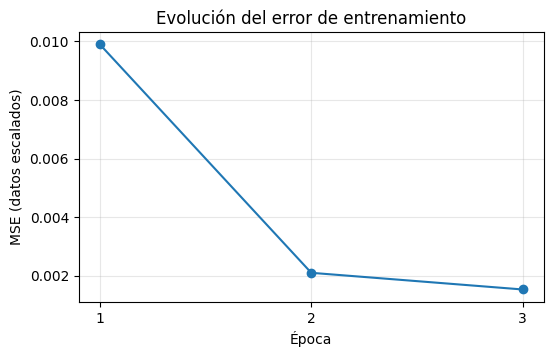

In [21]:
import matplotlib.pyplot as plt

# Evolución de la pérdida (MSE) por época
perdidas = history.history['loss']
for i, l in enumerate(perdidas, start=1):
    print(f"Época {i}: MSE = {l:.5f}")

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(perdidas) + 1), perdidas, marker='o')
plt.title('Evolución del error de entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE (datos escalados)')
plt.xticks(range(1, len(perdidas) + 1))
plt.grid(alpha=0.3)
plt.show()

**Comentario — entrenamiento**

El error disminuye con cada época: el MSE pasa de 0,00989 en la primera época a 0,00210 en la segunda (−79 %) y a 0,00153 en la tercera (−27 %). El descenso es muy pronunciado al principio y más moderado después, lo que indica que el modelo aprende rápidamente el patrón principal de la serie y a partir de ahí solo realiza ajustes finos.

Para interpretarlo en puntos del índice: un MSE de 0,00153 en datos escalados equivale a un error típico de √0,00153 × 480,90 ≈ 19 puntos. Hay que tener en cuenta que este error está medido sobre el conjunto de entrenamiento; un error bajo aquí no garantiza un buen rendimiento fuera de muestra, que es lo que se evalúa en el siguiente apartado.

## 8. Aplicación del modelo al conjunto de test

Se evalúa el modelo sobre datos que no ha visto. Como se trata de una serie temporal, se vuelve a usar `TimeseriesGenerator`, esta vez con los datos de test, para respetar el orden temporal.

In [22]:
# Creamos el generador de test, usando los datos escalados reales del conjunto de test
generator_test = TimeseriesGenerator(scaled_test, scaled_test,
                                     length=ventana, batch_size=1)

# Predecimos directamente con el modelo usando los datos del test
predicciones_test = model.predict(generator_test)

print(f"Nº de predicciones: {len(predicciones_test)}  (= {len(test)} filas de test - {ventana} de ventana)")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
Nº de predicciones: 6  (= 21 filas de test - 15 de ventana)


Las predicciones están en escala estandarizada. Para interpretarlas en puntos del índice, se revierte la estandarización con `inverse_transform()` del **mismo** escalador. Después se guardan junto a los valores reales para compararlos.

In [23]:
# Convertimos las predicciones a la escala original (puntos del índice)
predicciones_reales = scaler.inverse_transform(predicciones_test)

# Alineamos los valores reales desde donde empieza el generador (por eso usamos [ventana:]):
# los primeros 15 días del test solo sirven de entrada, no tienen predicción
valores_reales = test[ventana:].copy()
valores_reales['prediccion'] = predicciones_reales

# Añadimos el error de cada día (predicción - real) para analizarlo
valores_reales['error'] = valores_reales['prediccion'] - valores_reales['spx']
valores_reales.round(2)

,spx,prediccion,error
date,,,
2018-01-22,2832.97,2816.510010,-16.46
2018-01-23,2839.13,2838.649902,-0.48
2018-01-24,2837.54,2847.520020,9.98
2018-01-25,2839.25,2845.419922,6.17
2018-01-26,2872.87,2844.989990,-27.87
2018-01-29,2853.53,2875.610107,22.08


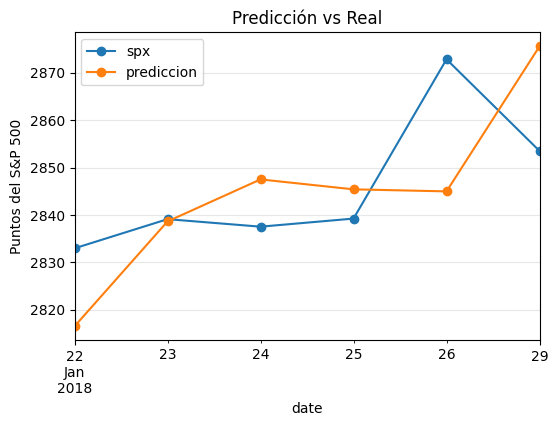

In [24]:
# Graficamos para ver cómo se comporta el modelo frente a los valores reales
valores_reales[['spx', 'prediccion']].plot(figsize=(6, 4), title='Predicción vs Real', marker='o')
plt.ylabel('Puntos del S&P 500')
plt.grid(alpha=0.3)
plt.show()

**Comentario — predicción frente a valor real**

La tabla y el gráfico muestran que las predicciones siguen de cerca el nivel del índice: los errores diarios oscilan entre −27,87 y +22,08 puntos y cambian de signo, sin una tendencia clara a sobreestimar o infraestimar. Los días más difíciles son el 26/01, cuando el índice subió con fuerza y el modelo se quedó corto, y el 29/01, cuando el modelo trasladó esa subida a su predicción mientras el mercado caía. Este patrón de reacción con un día de retraso se analiza en detalle en el apartado 9.

## 9. Evaluación complementaria: comparación con un modelo ingenuo

El gráfico por sí solo no permite saber si el modelo aporta valor. Por eso se calculan métricas de error y se compara la LSTM con el modelo más sencillo posible, el **modelo ingenuo** (*naïve*), que predice que el precio de mañana será igual al de hoy.

Si la LSTM no mejora al modelo ingenuo, su complejidad no está justificada.

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Modelo ingenuo: la predicción de cada día es el precio de cierre del día anterior
valores_reales['naive'] = test['spx'].shift(1)[ventana:]

# Métricas en puntos del índice
resultados = {}
for columna, nombre in [('prediccion', 'LSTM'), ('naive', 'Ingenuo')]:
    mae = mean_absolute_error(valores_reales['spx'], valores_reales[columna])
    rmse = np.sqrt(mean_squared_error(valores_reales['spx'], valores_reales[columna]))
    mape = (abs(valores_reales[columna] - valores_reales['spx']) / valores_reales['spx']).mean() * 100
    resultados[nombre] = {'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}

tabla_metricas = pd.DataFrame(resultados).T.round(2)
tabla_metricas

,MAE,RMSE,MAPE (%)
LSTM,13.84,16.70,0.49
Ingenuo,14.18,18.54,0.50


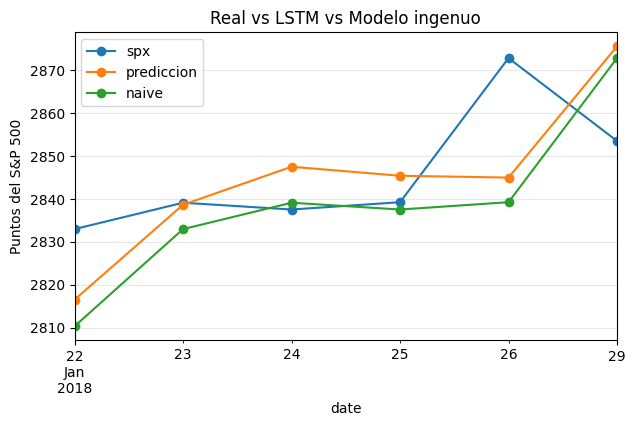

Error medio de la LSTM (sesgo): -1.10 puntos → infraestima el precio real en promedio


In [26]:
# Gráfico comparativo: real vs LSTM vs modelo ingenuo
valores_reales[['spx', 'prediccion', 'naive']].plot(
    figsize=(7, 4), marker='o', title='Real vs LSTM vs Modelo ingenuo')
plt.ylabel('Puntos del S&P 500')
plt.grid(alpha=0.3)
plt.show()

# Sesgo medio de la LSTM: positivo = sobreestima, negativo = infraestima
sesgo = valores_reales['error'].mean()
print(f"Error medio de la LSTM (sesgo): {sesgo:+.2f} puntos → "
      f"{'sobreestima' if sesgo > 0 else 'infraestima'} el precio real en promedio")

In [27]:
# Resumen automático de la comparación (apoya las conclusiones escritas)
mae_lstm, mae_naive = tabla_metricas.loc['LSTM', 'MAE'], tabla_metricas.loc['Ingenuo', 'MAE']
mejor = 'la LSTM' if mae_lstm < mae_naive else 'el modelo ingenuo'
print(f"MAE LSTM: {mae_lstm:.2f} puntos | MAE ingenuo: {mae_naive:.2f} puntos")
print(f"Con {len(valores_reales)} días de test, el modelo con menor error es {mejor}.")
print(f"La LSTM se equivoca de media un {tabla_metricas.loc['LSTM', 'MAPE (%)']:.2f}% sobre el precio real.")

MAE LSTM: 13.84 puntos | MAE ingenuo: 14.18 puntos
Con 6 días de test, el modelo con menor error es la LSTM.
La LSTM se equivoca de media un 0.49% sobre el precio real.


## Conclusiones

**Resultados.** En los 6 días evaluados (del 22 al 29 de enero de 2018), la LSTM obtiene un MAE de 13,84 puntos, un RMSE de 16,70 y un MAPE del 0,49 %, frente a 14,18, 18,54 y 0,50 % del modelo ingenuo. La LSTM mejora ligeramente al modelo ingenuo: 0,34 puntos de MAE (un 2 %) y un RMSE un 10 % inferior, lo que indica que comete errores grandes con algo menos de frecuencia.

**Qué ha aprendido realmente el modelo.** Al comparar cada predicción con el cierre del día anterior se observa que la LSTM predice, en esencia, **el precio de ayer más una pequeña subida**: entre +2,7 y +8,4 puntos en los días del 23 al 29 de enero. Es decir, reproduce el modelo ingenuo añadiendo una ligera tendencia alcista que extrae de la ventana de 15 días. Esto explica su pequeña ventaja: enero de 2018 fue un mes de fuerte subida (el índice pasó de 2.673,61 puntos el 29/12/2017 a 2.872,87 el 26/01/2018, un +7,5 %), y en ese contexto un modelo que añade una deriva alcista acierta más que uno que supone que el precio no cambia. El mismo mecanismo le perjudicaría en un cambio de tendencia, como la fuerte corrección que sufrió el mercado a principios de febrero de 2018, justo después del periodo de test.

**Retraso ante los movimientos.** Los mayores errores se producen en los días con movimientos bruscos. El 26/01 el índice subió 33,6 puntos y el modelo solo anticipó una subida de unos 6 puntos (error de −27,87). Al día siguiente hábil, el 29/01, el modelo trasladó esa subida a su predicción (2.875,61) mientras el mercado caía hasta 2.853,53 (error de +22,08). El modelo reacciona a los movimientos, pero no los anticipa.

**Sesgo.** El error medio es de −1,10 puntos, por lo que en esta ejecución no hay un sesgo sistemático. El gráfico del enunciado, con el mismo código, mostraba predicciones sistemáticamente por debajo del valor real. La diferencia se debe a la inicialización aleatoria de los pesos: en este notebook se ha fijado una semilla (`keras.utils.set_random_seed(42)`), por lo que los resultados son reproducibles y se obtienen los mismos valores en cada ejecución; sin fijarla, como en el enunciado, las predicciones cambian notablemente de una ejecución a otra con solo 3 épocas de entrenamiento.

**Limitaciones de la evaluación.** Con solo 6 predicciones, una diferencia de 0,34 puntos de MAE no es estadísticamente significativa. Además, se trata de una única ejecución, con 3 épocas y una sola arquitectura, por lo que no se puede afirmar que el modelo esté optimizado ni que su ventaja sea estable.

**Posibles mejoras.**
- Modelizar **rentabilidades** en lugar de precios, lo que elimina la tendencia y el problema de extrapolación detectado en la normalización.
- Ampliar el periodo de test (por ejemplo, reservar los últimos 2–3 años) para evaluar el modelo en distintos regímenes de mercado, incluidas fases bajistas.
- Probar distintas ventanas, número de neuronas y épocas, usando un conjunto de validación y *early stopping*, y repetir el entrenamiento con varias semillas para medir la estabilidad de los resultados.
- Incorporar como variables explicativas los otros índices del archivo (DAX, FTSE y NIKKEI), aprovechando que los mercados asiáticos y europeos cierran antes que el estadounidense.

**Valoración final.** Desde mi perspectiva profesional en banca, la conclusión principal es que un error bajo en términos de precio no implica capacidad predictiva. Un MAPE del 0,49 % parece excelente, pero el modelo ingenuo consigue prácticamente lo mismo sin ningún entrenamiento. En la validación de modelos de riesgo, un modelo solo aporta valor si supera de forma consistente a una referencia sencilla en un periodo suficientemente amplio y en distintos escenarios de mercado. Con la evidencia disponible, esta LSTM no cumple todavía ese estándar: su ligera ventaja se explica por la tendencia alcista de un único mes.